# Level 3 — Skin wound neighborhood theme analysis (per-cell)

Per-cell functional **signature scoring** for the nine wound-biology themes
requested by the collaborator, read out in a spatial / neighborhood context.

For each theme we (1) define a gene signature restricted to genes on the Xenium
panel, (2) compute a per-cell module score (`sc.tl.score_genes`), and (3)
summarize those scores spatially, per **cell lineage (compartment)**, and per
**CellCharter niche** (k=12).

**Themes:** wound healing & epithelial repair · vascular repair · immunity &
recruitment · inflammation & resolution · fibrosis & matrix remodeling ·
neuroimmune signaling · pain & sensory transduction · neuropeptides & receptors ·
neurogenic inflammation.

> **⚠️ Caveat (see final cell):** the four *neuro/sensory* themes have very low
> signal in this dataset. The genes are on the panel, but sensory-neuron cell
> bodies (which express them) reside in the dorsal root ganglia, not the skin —
> the skin contains only thin axons that Xenium does not segment into cells.
> Interpret per-cell pain/neuropeptide scores with caution.

Input: `../../data/talbot_xenium_skin_annotated_cellcharter.h5ad` (log-normalized
`X`, CyteType annotation, CellCharter niches, `obsm['spatial']`).

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import warnings; warnings.filterwarnings('ignore')
sc.settings.verbosity = 1

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Load object + define compartments (coarse cell lineages)

In [2]:
adata = sc.read_h5ad('../../data/talbot_xenium_skin_annotated_cellcharter.h5ad')
ANNOT = 'cytetype_annotation_leiden_4'
NICHE = 'CellCharter_12'

def coarse(s):
    s = s.lower()
    if 'doublet' in s or 'mixed' in s: return 'Mixed'
    if any(k in s for k in ['macrophage','myeloid','dendritic','mast','neutro',
                            'monocyte','langerhans','immune','t cell','b cell','lymph']):
        return 'Immune'
    if any(k in s for k in ['endothel','vascular','vessel','lymphatic']): return 'Endothelial'
    if 'fibro' in s or 'stromal' in s: return 'Fibroblast'
    if 'muscle' in s or 'myocyte' in s: return 'Muscle'
    if 'adipo' in s: return 'Adipocyte'
    if any(k in s for k in ['kerat','epithel','epiderm']): return 'Keratinocyte'
    if any(k in s for k in ['schwann','neuro','glia','nerve','melanocyte']): return 'Neural/Melanocyte'
    return 'Other'

adata.obs['compartment'] = adata.obs[ANNOT].astype(str).map(coarse)
print(adata.obs['compartment'].value_counts())
adata

compartment
Keratinocyte    27078
Immune          18083
Fibroblast      14921
Endothelial      8932
Muscle           4698
Adipocyte        2429
Other             954
Mixed             306
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 77401 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4', '_scvi_batch', '_scvi_labels', 'CellCharter_8', 'CellCharter_10', 'CellCharter_12', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cytetype_annotation_leiden_4_colors', 'cytetype_jobDetails', 'cytetype_results', 'genotyp

## Theme gene signatures (restricted to the Xenium panel)

In [3]:
THEMES = {
    'wound_healing':          ['Lgr5','Lgr6','Wnt5a','Wnt4','Fgf7','Egfr','Ereg','Tgfb1','Ctnnb1','Itgb1','Itgb4','Lamb3','Cdh1','Timp1','Serpine1'],
    'vascular_repair':        ['Pecam1','Cdh5','Vwf','Kdr','Flt1','Flt4','Tek','Vegfa','Vegfc','Angpt1','Angpt2','Nos3','Notch1','Dll4','Hey1','Eng','Pdgfrb','Cspg4'],
    'immunity_recruitment':   ['Ptprc','Cd3e','Cd4','Cd8a','Cd19','Ms4a1','Cd68','Adgre1','Itgam','Ccr2','Ccl2','Ccl3','Cxcl1','Cxcl2','Cxcl9','Cxcl10','Cxcl12','Ccr7','Sell','Il7r','Cd14'],
    'inflammation_resolution':['Tnf','Nfkb1','Ptgs2','Nlrp3','Il10','Tgfb1','Arg1','Mrc1','Chil3','Alox15','Fpr2','Il4','Il13','Socs3','Foxp3','Nos2'],
    'fibrosis_matrix':        ['Col1a1','Col1a2','Col5a1','Col6a1','Fn1','Tagln','Postn','Timp1','Mmp2','Mmp9','Mmp13','Mmp14','Lox','Loxl1','Fbn1','Eln','Tgfb1','Pdgfra','Pdgfrb','Lum'],
    'neuroimmune':            ['Ngf','Bdnf','Ntrk1','Ntrk2','Gfra1','Ret','Nrg1','Cx3cl1','Cx3cr1','Csf1','Csf1r','Il31','Osm','Osmr','Tslp','Crlf2'],
    'pain_sensory':           ['Trpv1','Trpa1','Trpm8','Scn9a','Scn10a','Piezo2','Piezo1','Asic1','Asic3','P2rx3','P2rx7','Gfra3','Runx1','Trpv4','Kcnq3'],
    'neuropeptides':          ['Calcr','Calcrl','Tac1','Tacr1','Tacr2','Vip','Vipr1','Vipr2','Npy1r','Sst','Sstr2','Gal','Galr1','Pnoc','Oprm1','Oprd1','Oprk1','Adcyap1','Nppb','Grp','Grpr','Nmb'],
    'neurogenic_inflammation':['Tac1','Tacr1','Trpv1','Trpa1','Adcyap1','Vip','Hrh1','Ccl2','Ngf'],
}
THEME_LABEL = {
    'wound_healing':'Wound healing & epithelial repair',
    'vascular_repair':'Vascular repair',
    'immunity_recruitment':'Immunity & recruitment',
    'inflammation_resolution':'Inflammation & resolution',
    'fibrosis_matrix':'Fibrosis & matrix remodeling',
    'neuroimmune':'Neuroimmune signaling',
    'pain_sensory':'Pain & sensory transduction',
    'neuropeptides':'Neuropeptides & receptors',
    'neurogenic_inflammation':'Neurogenic inflammation',
}
panel = set(map(str, adata.var_names))
cov = []
for t, gs in THEMES.items():
    on = [g for g in gs if g in panel]
    THEMES[t] = on
    cov.append({'theme': t, 'label': THEME_LABEL[t], 'n_genes_on_panel': len(on),
                'genes': ';'.join(on)})
cov = pd.DataFrame(cov)
os.makedirs('../../results/cell-driven-analysis', exist_ok=True)
cov.to_csv('../../results/cell-driven-analysis/skin_wound_theme_gene_panel.csv', index=False)
cov[['theme','n_genes_on_panel']]

,theme,n_genes_on_panel
0,wound_healing,15
1,vascular_repair,18
2,immunity_recruitment,21
3,inflammation_resolution,16
4,fibrosis_matrix,20
5,neuroimmune,16
6,pain_sensory,15
7,neuropeptides,22
8,neurogenic_inflammation,9


## Per-cell module scores (`sc.tl.score_genes`)

In [4]:
score_cols = []
for t, gs in THEMES.items():
    col = f'{t}_score'
    sc.tl.score_genes(adata, gene_list=gs, score_name=col, ctrl_size=50, random_state=0)
    score_cols.append(col)
adata.obs[score_cols].describe().T[['mean','std','min','max']]

,mean,std,min,max
wound_healing_score,0.023113,0.056461,-0.059322,0.465648
vascular_repair_score,-0.005412,0.033678,-0.043246,0.406673
immunity_recruitment_score,-0.001695,0.039766,-0.041386,0.352187
inflammation_resolution_score,0.000684,0.034477,-0.036968,0.346772
fibrosis_matrix_score,0.041779,0.105333,-0.069977,0.563548
neuroimmune_score,-0.002299,0.023559,-0.029644,0.281236
pain_sensory_score,-0.001545,0.015870,-0.032928,0.203079
neuropeptides_score,-0.000620,0.007489,-0.024683,0.128824
neurogenic_inflammation_score,-0.010585,0.031271,-0.050883,0.392490


## Spatial maps of each theme score (per condition, 6 panels)

Continuous per-cell score, shared 1st–99th-percentile color scale within each
theme so panels are comparable across conditions.

In [5]:
CONDS = ['litt_24h','cre_24h','wt_24h','litt_72h','cre_72h','wt_72h']

def plot_score_by_condition(ad, score_col, out_stem=None, cmap='magma',
                            spot_size=2.0, cols=3, title=None):
    coords = np.asarray(ad.obsm['spatial'])[:, :2]
    vals = ad.obs[score_col].to_numpy()
    vmin, vmax = np.percentile(vals, [1, 99])
    if vmin == vmax:
        vmin, vmax = float(vals.min()), float(vals.max() + 1e-9)
    conds = [c for c in CONDS if c in set(ad.obs['condition'].astype(str))]
    n = len(conds); ncol = min(cols, n); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.4, nrow * 3.4), dpi=110)
    axes = np.atleast_1d(axes).ravel()
    cond = ad.obs['condition'].astype(str).to_numpy()
    sca = None
    for ax, cnd in zip(axes, conds):
        m = cond == cnd
        order = np.argsort(vals[m])          # draw high-score cells on top
        sca = ax.scatter(coords[m, 0][order], coords[m, 1][order], s=spot_size,
                         c=vals[m][order], cmap=cmap, vmin=vmin, vmax=vmax,
                         linewidths=0, rasterized=True)
        ax.set_title(cnd, fontsize=9)
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    cbar = fig.colorbar(sca, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label('module score', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    if out_stem:
        os.makedirs(os.path.dirname(out_stem), exist_ok=True)
        fig.savefig(out_stem + '.png', dpi=110, bbox_inches='tight')
        fig.savefig(out_stem + '.pdf', bbox_inches='tight')
        print('saved', out_stem + '.png/.pdf')
    plt.show()

saved ../../results/spatial-tissue-maps/skin_wound_theme_wound_healing_by_condition.png/.pdf


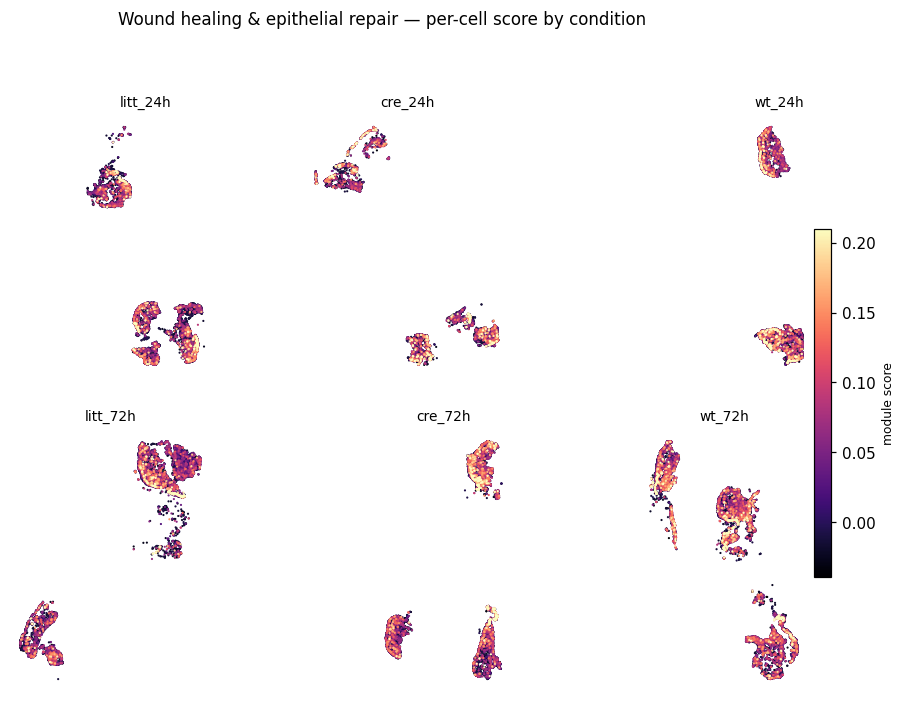

saved ../../results/spatial-tissue-maps/skin_wound_theme_vascular_repair_by_condition.png/.pdf


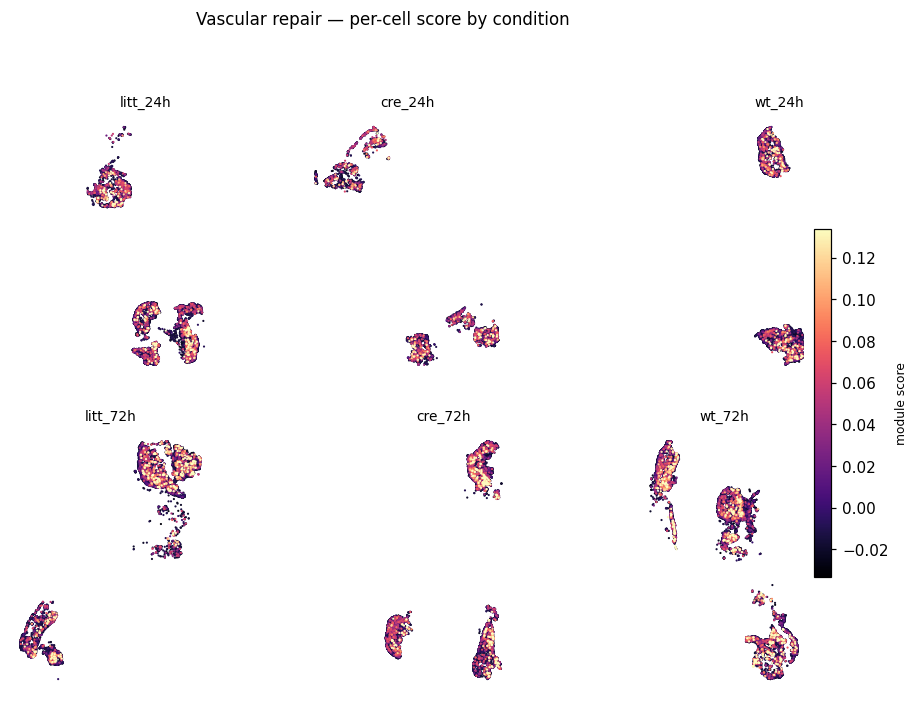

saved ../../results/spatial-tissue-maps/skin_wound_theme_immunity_recruitment_by_condition.png/.pdf


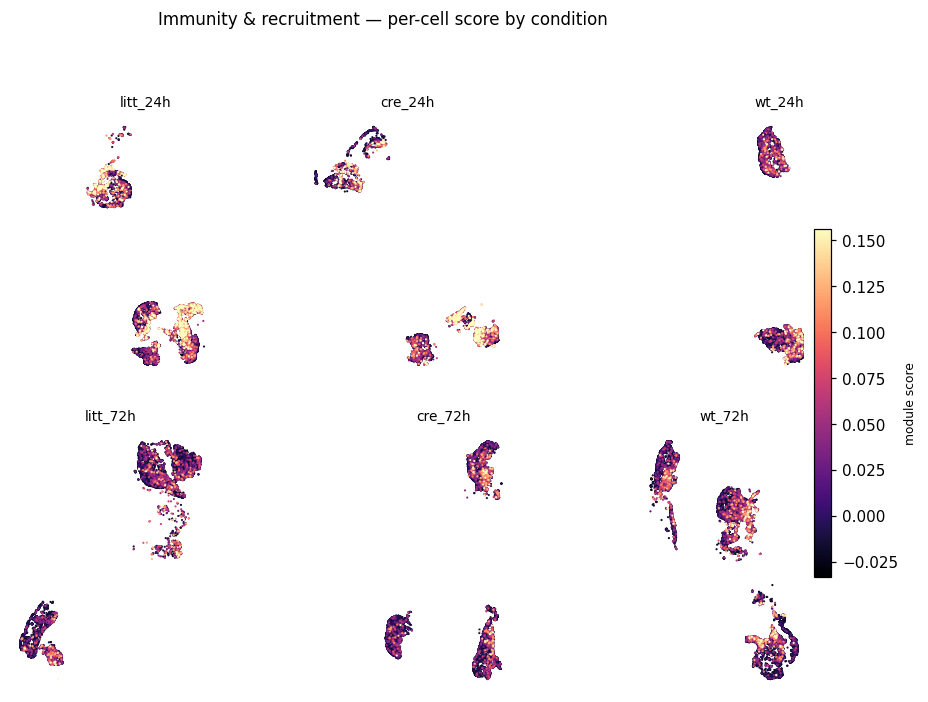

saved ../../results/spatial-tissue-maps/skin_wound_theme_inflammation_resolution_by_condition.png/.pdf


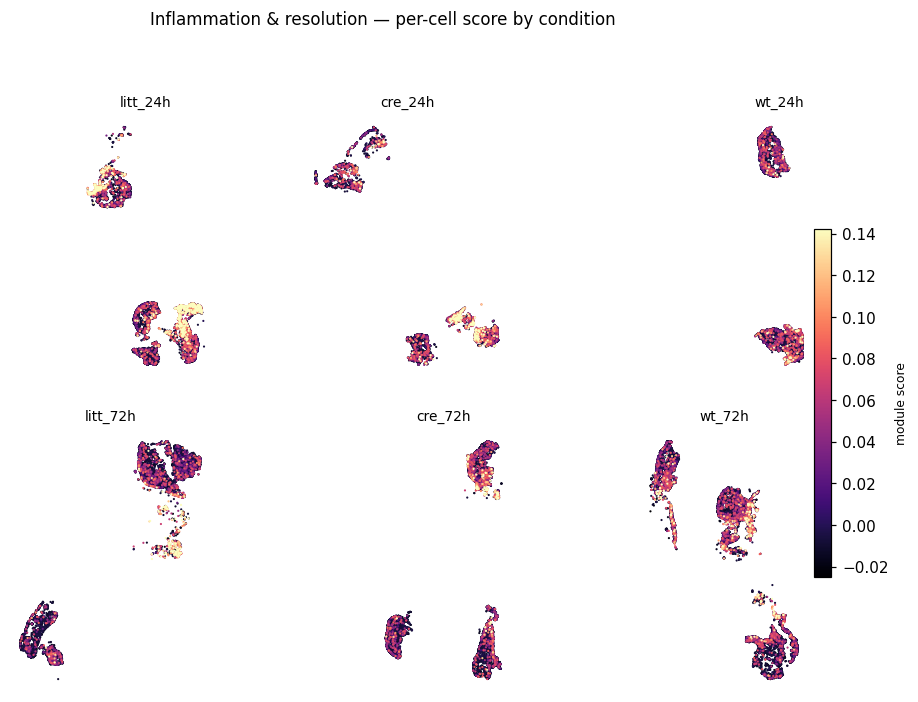

saved ../../results/spatial-tissue-maps/skin_wound_theme_fibrosis_matrix_by_condition.png/.pdf


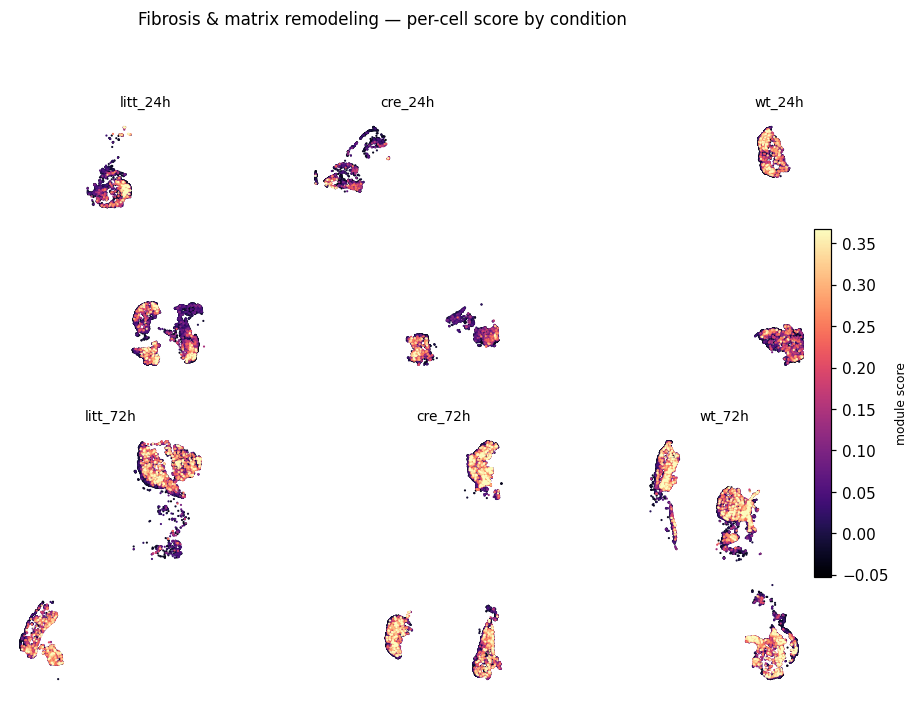

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuroimmune_by_condition.png/.pdf


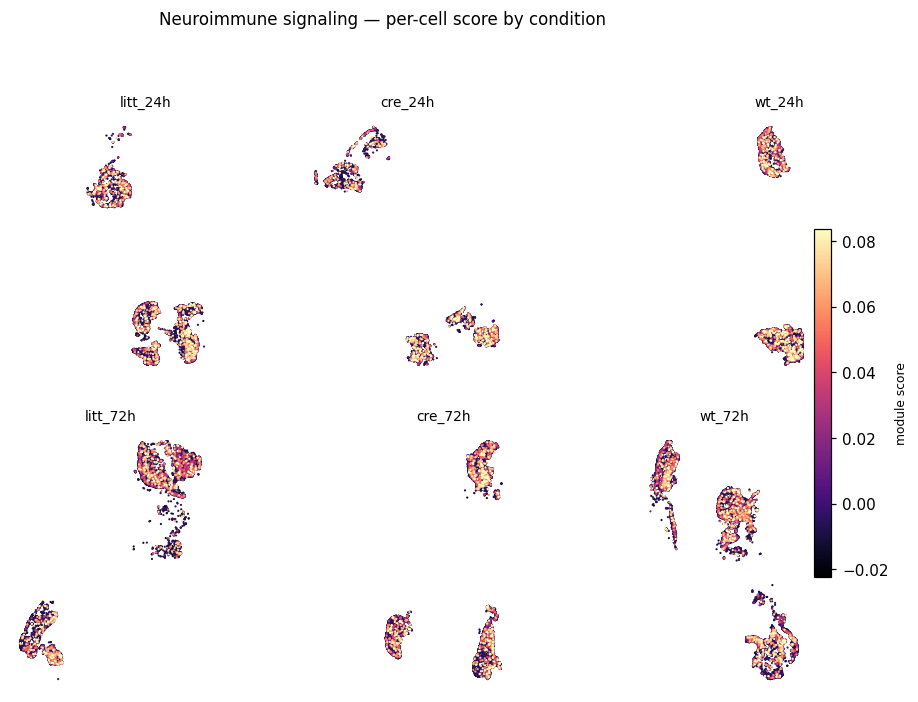

saved ../../results/spatial-tissue-maps/skin_wound_theme_pain_sensory_by_condition.png/.pdf


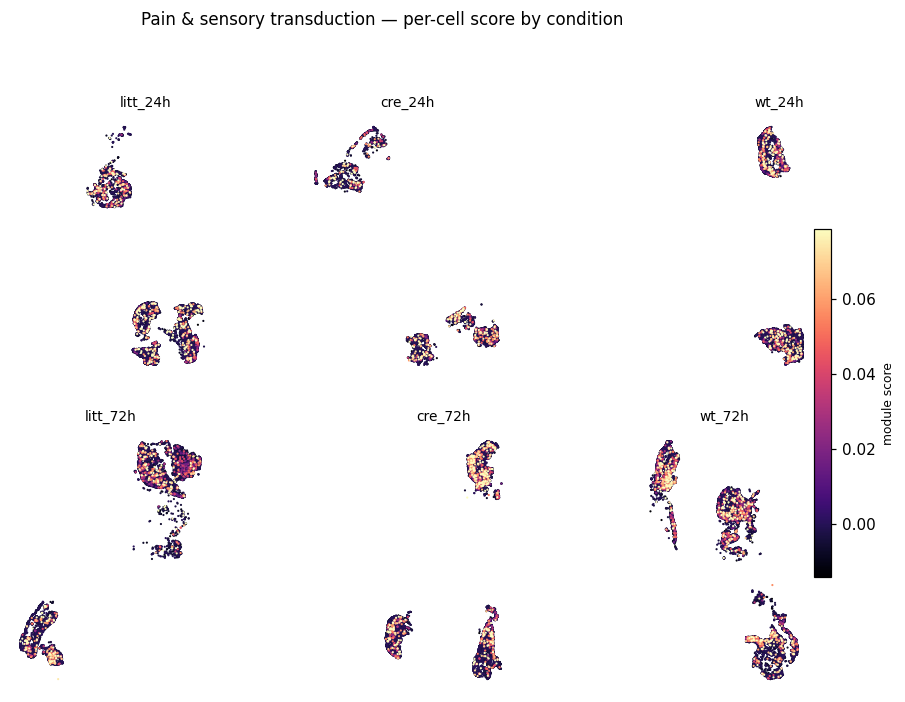

saved ../../results/spatial-tissue-maps/skin_wound_theme_neuropeptides_by_condition.png/.pdf


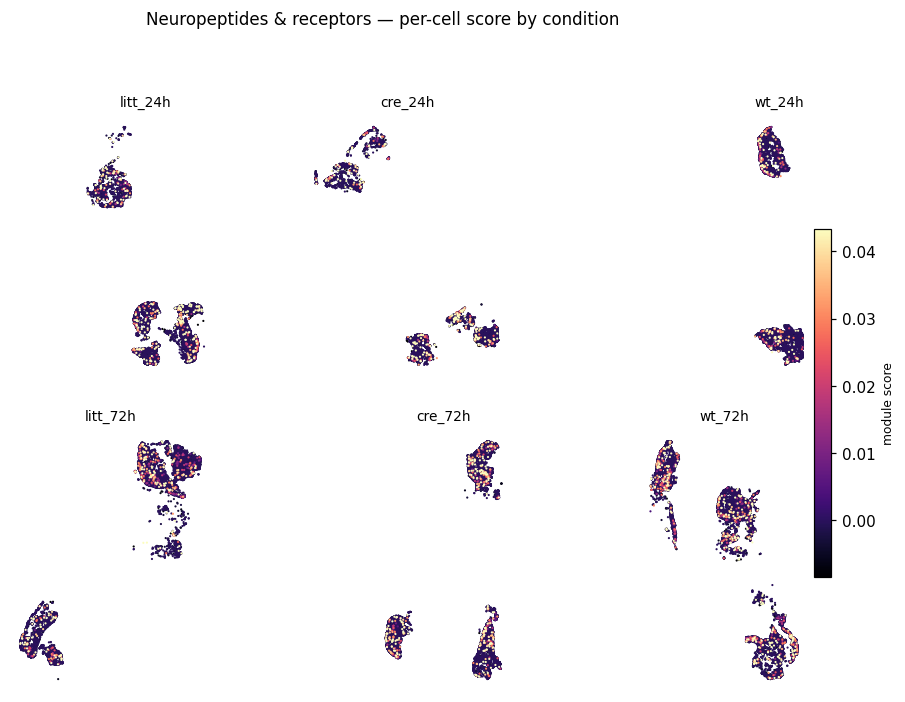

saved ../../results/spatial-tissue-maps/skin_wound_theme_neurogenic_inflammation_by_condition.png/.pdf


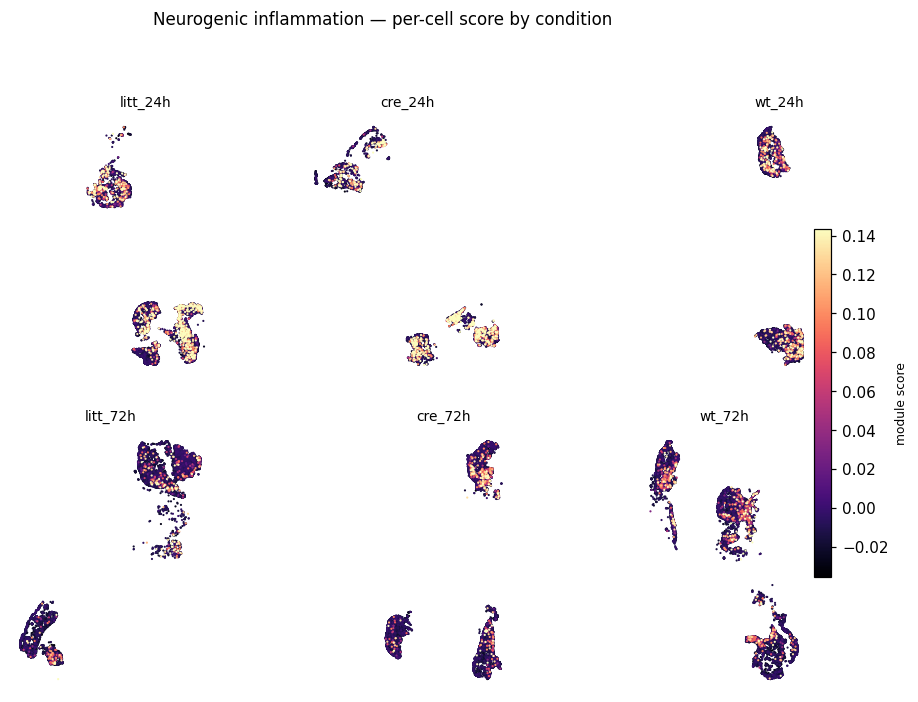

In [6]:
for t in THEMES:
    plot_score_by_condition(
        adata, f'{t}_score',
        out_stem=f'../../results/spatial-tissue-maps/skin_wound_theme_{t}_by_condition',
        title=f'{THEME_LABEL[t]} — per-cell score by condition')

## Neighborhood summaries — theme × compartment and theme × niche

Mean per-cell score in each **cell lineage** and each **CellCharter niche**
(z-scored across groups within a theme for the heatmap; raw means saved to CSV).

saved ../../results/cell-driven-analysis/skin_wound_theme_by_compartment.png/.pdf/.csv


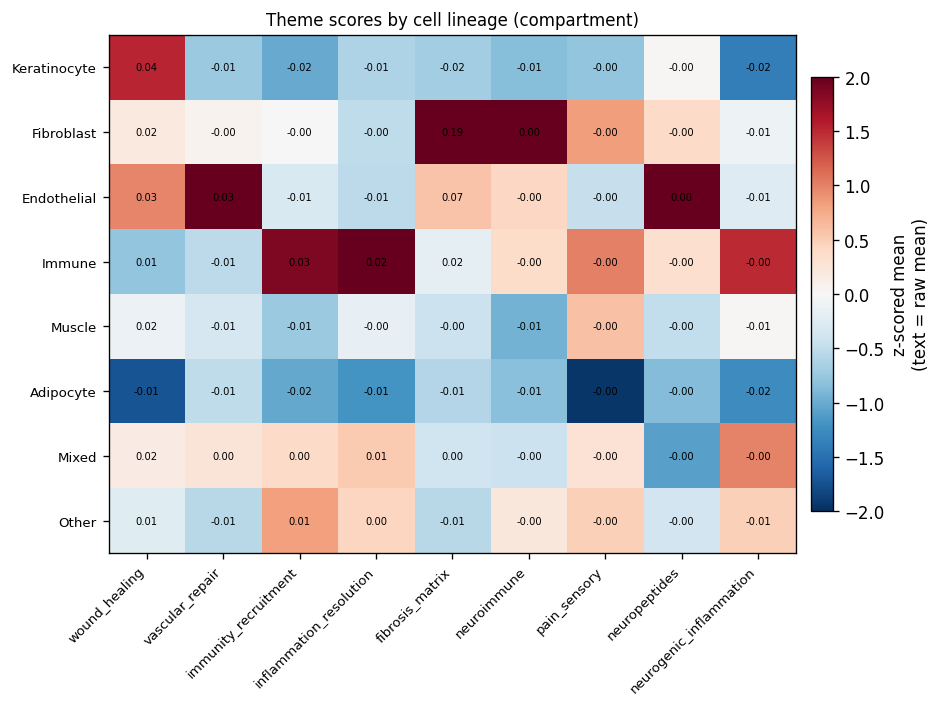

In [7]:
def summary_heatmap(ad, group_col, out_stem, title):
    M = ad.obs.groupby(group_col, observed=True)[score_cols].mean()
    M.columns = [c.replace('_score','') for c in M.columns]
    M.to_csv(out_stem + '.csv')
    Z = (M - M.mean(axis=0)) / (M.std(axis=0) + 1e-9)   # z-score each theme across groups
    fig, ax = plt.subplots(figsize=(0.55*Z.shape[1]+3, 0.5*Z.shape[0]+2), dpi=120)
    im = ax.imshow(Z.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(Z.shape[1])); ax.set_xticklabels(Z.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(Z.shape[0])); ax.set_yticklabels(Z.index, fontsize=8)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            ax.text(j, i, f'{M.values[i,j]:.2f}', ha='center', va='center', fontsize=6,
                    color='black')
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='z-scored mean\n(text = raw mean)')
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_stem + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(out_stem + '.pdf', bbox_inches='tight')
    print('saved', out_stem + '.png/.pdf/.csv')
    plt.show()
    return M

comp_order = [c for c in ['Keratinocyte','Fibroblast','Endothelial','Immune','Muscle',
                          'Adipocyte','Neural/Melanocyte','Mixed','Other']
              if c in set(adata.obs['compartment'])]
adata.obs['compartment'] = pd.Categorical(adata.obs['compartment'], categories=comp_order)
M_comp = summary_heatmap(adata, 'compartment',
    '../../results/cell-driven-analysis/skin_wound_theme_by_compartment',
    'Theme scores by cell lineage (compartment)')

saved ../../results/cell-driven-analysis/skin_wound_theme_by_niche_k12.png/.pdf/.csv


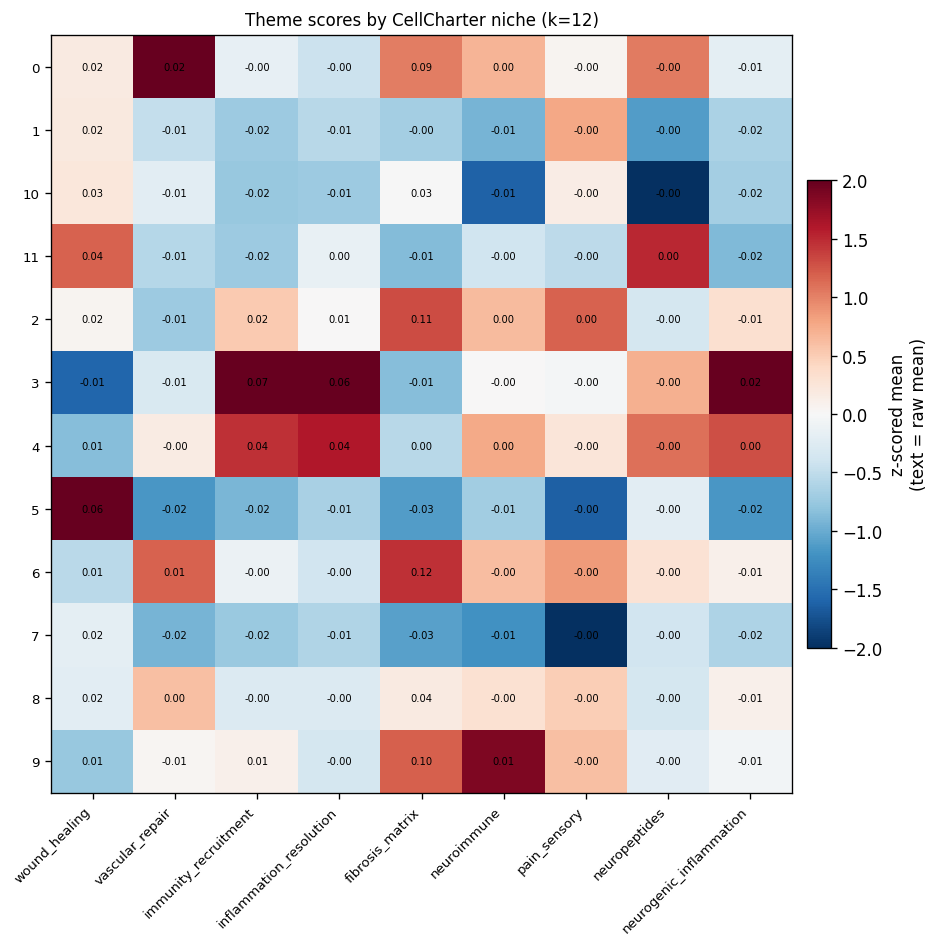

In [8]:
M_niche = summary_heatmap(adata, NICHE,
    '../../results/cell-driven-analysis/skin_wound_theme_by_niche_k12',
    'Theme scores by CellCharter niche (k=12)')

## Per-cell export (all theme scores + compartment + niche)

In [9]:
sp_xy = np.asarray(adata.obsm['spatial'])[:, :2]
out = pd.DataFrame({
    'cell_id': adata.obs_names,
    'x': sp_xy[:, 0], 'y': sp_xy[:, 1],
    'sample_id': adata.obs['sample_id'].astype(str).values,
    'condition': adata.obs['condition'].astype(str).values,
    'genotype': adata.obs['genotype'].astype(str).values,
    'cell_type': adata.obs[ANNOT].astype(str).values,
    'compartment': adata.obs['compartment'].astype(str).values,
    'niche_k12': adata.obs[NICHE].astype(str).values,
})
for c in score_cols:
    out[c] = adata.obs[c].values
out.to_csv('../../results/cell-driven-analysis/skin_wound_cell_theme_scores.csv', index=False)
print('wrote', out.shape, 'to skin_wound_cell_theme_scores.csv')
out.head()

wrote (77401, 18) to skin_wound_cell_theme_scores.csv


,cell_id,x,y,sample_id,condition,genotype,cell_type,compartment,niche_k12,wound_healing_score,vascular_repair_score,immunity_recruitment_score,inflammation_resolution_score,fibrosis_matrix_score,neuroimmune_score,pain_sensory_score,neuropeptides_score,neurogenic_inflammation_score
0,output-XETG00045__0059976__litt_24h__20250725_...,368.014587,3811.147461,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Inflammatory Macrophage (GRN+ chemokine),Immune,4,0.048724,-0.029470,0.028426,0.180704,-0.027625,-0.017593,-0.002304,0.000000,0.000000
1,output-XETG00045__0059976__litt_24h__20250725_...,389.098480,3823.478516,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Interferon-Responsive Regulatory Macrophage,Immune,4,0.041140,-0.023924,0.101365,-0.005910,0.002481,0.040815,-0.009316,-0.002073,-0.012339
2,output-XETG00045__0059976__litt_24h__20250725_...,450.419128,3818.730469,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Stressed Skeletal Muscle Fiber (glycolytic),Muscle,4,-0.020921,0.019363,0.149482,0.116371,0.005875,-0.016932,-0.007210,-0.001604,0.061218
3,output-XETG00045__0059976__litt_24h__20250725_...,376.878601,3817.675049,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,Interferon-Responsive Regulatory Macrophage,Immune,4,0.024966,-0.028409,0.004842,0.108308,-0.032898,-0.011551,-0.001421,-0.001580,-0.021552
4,output-XETG00045__0059976__litt_24h__20250725_...,375.687622,3810.113525,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,litt,M2-like Macrophage,Immune,4,0.018155,-0.024903,0.011284,0.059223,-0.042670,-0.015630,-0.010926,-0.004812,-0.019062


## ⚠️ Interpretation note — neuro/sensory themes

The compartment/niche summaries above show that the five **tissue-repair themes**
(wound healing, vascular, immunity, inflammation, fibrosis) map cleanly onto the
expected lineages and carry real signal.

The four **neuro/sensory themes** (neuroimmune, pain & sensory transduction,
neuropeptides, neurogenic inflammation) are near-zero across every compartment.
This is expected biology, not a pipeline artifact: the neurons that express these
programs (`Trpv1`, `Scn10a`, `Calca/Tac1`, neuropeptides) have their cell bodies
in the **dorsal root ganglia**, not the skin. The skin contains only thin free
nerve endings/axons, which Xenium does not segment into whole cells. **Per-cell**
scores for these themes should therefore be treated as low-confidence; a
neighborhood-level readout (do keratinocytes/immune cells *adjacent to* sparse
neuropeptide-receptor signal upregulate neurogenic-inflammation programs?) is the
more defensible framing if these themes are pursued.